In [1]:
from datasets import load_dataset

/stage/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = load_dataset("allenai/IF_multi_constraints_upto5", split="train", revision="main")

print(dataset[0])

{'key': 'ai2-adapt-dev/tulu_v3.9_aya_100k_79773', 'messages': [{'content': 'Identificeer welk instrument een snaar- of slaginstrument is: Kpanlogo, Shamisen. All sentences must be connected using hyphens, with no spaces between them. The last word of your response should be the word brief.', 'role': 'user'}], 'ground_truth': "[{'instruction_id': ['detectable_format:sentence_hyphens', 'last_word:last_word_answer'], 'kwargs': [None, {'last_word': 'brief'}]}]", 'dataset': 'ifeval', 'constraint_type': 'multi', 'constraint': 'All sentences must be connected using hyphens, with no spaces between them.\tThe last word of your response should be the word brief.'}


In [40]:
dataset

Dataset({
    features: ['key', 'messages', 'ground_truth', 'dataset', 'constraint_type', 'constraint'],
    num_rows: 95373
})

In [5]:
sample = dataset[0]

for k,v in sample.items():
    print(k, type(v), v.shape if hasattr(v, "shape") else len(v))
    print(v)
    print()


key <class 'str'> 38
ai2-adapt-dev/tulu_v3.9_aya_100k_79773

messages <class 'list'> 1
[{'content': 'Identificeer welk instrument een snaar- of slaginstrument is: Kpanlogo, Shamisen. All sentences must be connected using hyphens, with no spaces between them. The last word of your response should be the word brief.', 'role': 'user'}]

ground_truth <class 'str'> 132
[{'instruction_id': ['detectable_format:sentence_hyphens', 'last_word:last_word_answer'], 'kwargs': [None, {'last_word': 'brief'}]}]

dataset <class 'str'> 6
ifeval

constraint_type <class 'str'> 5
multi

constraint <class 'str'> 132
All sentences must be connected using hyphens, with no spaces between them.	The last word of your response should be the word brief.



In [16]:
from transformers import AutoTokenizer
from tqdm import tqdm, trange
import matplotlib.pyplot as plt

tokenizer = AutoTokenizer.from_pretrained("allenai/Llama-3.1-Tulu-3-8B-DPO")

In [36]:
def token_length(text):
    return len(tokenizer.encode(text))

In [ ]:
lens = []
for i in trange(len(dataset)):
    sample = dataset[i]
    lens.append(token_length(sample['messages'][0]['content']))

100%|████████████████████████████████████████████████████████████████████████████████████████████████| 95373/95373 [01:05<00:00, 1446.75it/s]


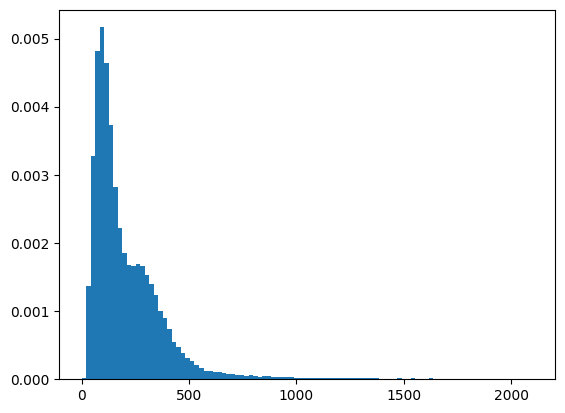

In [26]:
plt.hist(lens, range=(0, 2100), bins=100)
plt.show()

In [ ]:
import pandas as pd

df = pd.read_json("IFBench/data/sample_output.jsonl", lines=True)

In [37]:
df["prompt_length"] = df["prompt"].apply(token_length)
df["response_length"] = df["response"].apply(token_length)

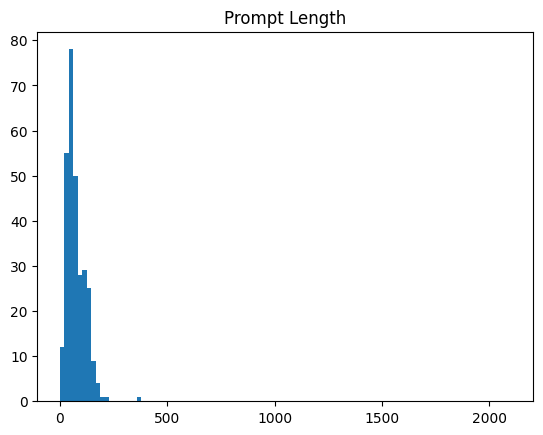

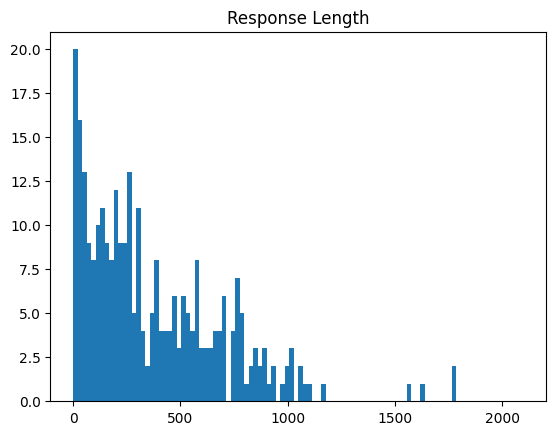

In [39]:
plt.hist(df["prompt_length"], range=(0, 2100), bins=100)
plt.title("Prompt Length")
plt.show()
plt.hist(df["response_length"], range=(0, 2100), bins=100)
plt.title("Response Length")
plt.show()
